In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e = 3.795                 
hbar_c = 1973.0              
mc2 = 0.511e6                

hbar2_over_2m = (hbar_c**2) / (2 * mc2) 

In [34]:
import numpy as np

def hamiltonian_matrix(delta_r,potential_values):
  potential_values = np.asarray(potential_values,dtype=float)
  if delta_r <=0:
    raise ValueError("detla_r must be greater than 0")
  if potential_values.ndim != 1:
    raise ValueError("potential_values must be a one-dimensional array.")
  if potential_values.size == 0:
    raise ValueError("potential_values cannot be empty.")

  interior_points = len(potential_values)

  main_diag = (2*hbar2_over_2m)/(delta_r**2) + potential_values
  off_diag = np.full(interior_points-1,(-1*hbar2_over_2m)/(delta_r**2))

  hamiltonian = (np.diag(main_diag) + np.diag(off_diag,k=1) + np.diag(off_diag,k=-1))

  return hamiltonian

In [35]:
def effective_potential(r,l,potential):
    potential_values = potential + hbar2_over_2m*(l*(l+1)/(r**2))
    return potential_values

In [57]:
def hydrogen_atom(intergior_grid):
    return (-e**2)/intergior_grid

def solve_potential(ri,rf,interior_points,l,state_index):
    delta_r = (rf - ri)/(interior_points + 1)
    interior_grid = (ri + delta_r*np.arange(1,interior_points+1))

    potential = hydrogen_atom(interior_grid)
    potential_values = effective_potential(interior_grid,l,potential)

    H = hamiltonian_matrix(delta_r,potential_values)
    eigenvalues,eigenvectors = np.linalg.eigh(H)

    phi_interior   = eigenvectors[:,state_index]
    if phi_interior[np.argmax(np.abs(phi_interior))] < 0:
        phi_interior = -phi_interior
    energy_value   = eigenvalues[state_index]
    phi            = np.concatenate(([0.0],phi_interior,[0.0]))
    normalization  = np.sum(np.abs(phi)**2)*delta_r
    phi_normalized = phi/np.sqrt(normalization)
    full_grid      = np.concatenate(([ri],interior_grid,[rf]))
    
    return full_grid,phi_normalized,energy_value

In [58]:
def plot(full_grid,phi_normalized,energy_value):

    plt.plot(full_grid,phi_normalized,label=f"energy={energy_value:.2f} eV")
    plt.grid(True,alpha=0.7)
    plt.xlabel("Radial distance r(Å)")
    plt.ylabel("Radial wavefunction u(r)")
    plt.legend()
    plt.show()

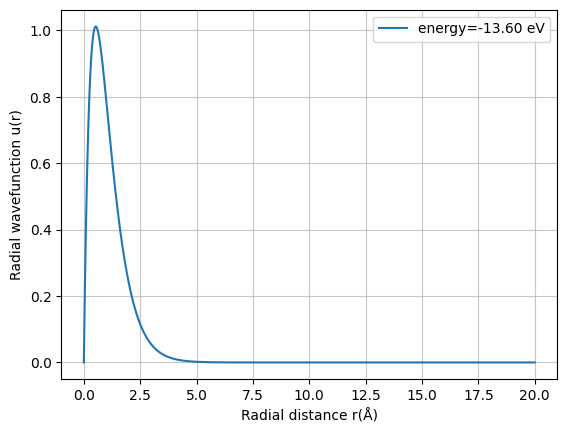

In [63]:
ri = 1e-4 
rf = 20.0  
interior_points = 2000
l = 0
state_index = 0
full_grid,phi_normalized,energy_value = solve_potential(ri,rf,interior_points,l,state_index)
plot(full_grid,phi_normalized,energy_value)